# Multilevel Graph with focus on NLP for now.

In [1]:
from typing import Any

import nltk
import glob
import random


In [2]:
pos_imdb = glob.glob("../data/datasets/IMDB/test/raw/positive/*.txt")
neg_imdb = glob.glob("../data/datasets/IMDB/test/raw/negative/*.txt")

imdb_test = pos_imdb + neg_imdb

random.shuffle(imdb_test)

selected_file = imdb_test[0]
print(f"Selected file: {selected_file}")
doc = open(selected_file).read()

print("-" * 50)
print(doc)
print("-" * 50)

Selected file: ../data/datasets/IMDB/test/raw/positive/49021.txt
--------------------------------------------------
Morte a Venezia is one of my favorite movies. More than beautiful, it's really sublime. It gives you important aesthetic experiences, it's a masterpiece. I also recommend the novel. Luchino Visconti is a genius.
--------------------------------------------------


In [3]:
doc = doc.replace("<br />", "\n")
print(doc)

Morte a Venezia is one of my favorite movies. More than beautiful, it's really sublime. It gives you important aesthetic experiences, it's a masterpiece. I also recommend the novel. Luchino Visconti is a genius.


In [4]:
sentences = nltk.sent_tokenize(doc)
[print(sentence) for sentence in sentences]

Morte a Venezia is one of my favorite movies.
More than beautiful, it's really sublime.
It gives you important aesthetic experiences, it's a masterpiece.
I also recommend the novel.
Luchino Visconti is a genius.


[None, None, None, None, None]

In [5]:
tokens_0 = nltk.word_tokenize(sentences[0].lower().strip())
print(tokens_0)

['morte', 'a', 'venezia', 'is', 'one', 'of', 'my', 'favorite', 'movies', '.']


## Char N-Grams

In [6]:
import os
from collections import Counter


def get_char_ngrams(text, n):
    return [text[i:i + n] for i in range(len(text) - n + 1)]


def clean_text(text):
    return text.lower().replace("<br />", "\n").replace("\ufeff", "")


def process_corpus(directory, n):
    ngram_counter = Counter()

    for filename in os.listdir(directory):
        if filename.endswith(".txt"):
            with open(os.path.join(directory, filename), "r", encoding="utf-8") as f:
                text = clean_text(f.read())  # normalize to lowercase
                ngrams = get_char_ngrams(text, n)
                ngram_counter.update(ngrams)

    return ngram_counter


# Usage
# directory_path = "../data/datasets/Imprisonment-IT/train/raw/NotReleased"
directory_path = "../data/datasets/IMDB/train/raw/positive"
n = 1  # for trigrams
top_ngrams = process_corpus(directory_path, n).most_common(20000)

# Display results
for ngram, count in top_ngrams:
    print(f"{ngram!r}: {count}")


' ': 4552936
'e': 2478186
't': 1913462
'a': 1683913
'i': 1598562
'o': 1518972
's': 1412966
'n': 1376644
'r': 1180558
'h': 1118604
'l': 922041
'd': 720991
'c': 585751
'm': 574724
'u': 541481
'f': 472129
'g': 426790
'y': 426668
'w': 400559
'p': 349637
'b': 321003
'v': 259758
'.': 252535
',': 226061
'k': 172302
"'": 100391
'\n': 77620
'-': 51511
'"': 50482
'j': 47645
'x': 35403
')': 29255
'(': 28797
'z': 19247
'!': 18690
'q': 16832
'0': 14985
'1': 14948
'9': 8744
'?': 7707
':': 7493
'2': 5862
';': 5767
'/': 5459
'*': 4420
'5': 4158
'8': 3934
'7': 3792
'3': 3771
'4': 3163
'6': 2678
'&': 2618
'é': 1141
'\x96': 1094
'\x85': 598
'`': 589
'_': 572
'$': 413
'=': 347
'%': 294
'+': 278
'\x97': 274
'#': 254
'´': 193
'á': 135
'}': 120
'{': 117
']': 115
'ö': 112
'[': 108
'>': 94
'è': 93
'\x91': 83
'’': 79
'~': 75
'@': 72
'ó': 62
'\t': 60
'ä': 56
'¨': 54
'ü': 50
'^': 49
'í': 48
'ñ': 43
'à': 41
'£': 40
'–': 37
'¡': 37
'ô': 36
'ï': 31
'ç': 30
'<': 30
'ã': 28
'\xa0': 26
'“': 25
'»': 25
'”': 24
'«': 23
'

# Preprocessing

In [7]:
import glob
import random
import tqdm
import nltk
import unicodedata
import re
import contractions
import nltk
import spacy
import glob

# Ensure necessary NLTK data is downloaded
nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)

# Load SpaCy English model
nlp = spacy.load('en_core_web_lg')


In [8]:

pos_imdb = glob.glob("../data/datasets/IMDB/train/raw/positive/*.txt")
neg_imdb = glob.glob("../data/datasets/IMDB/train/raw/negative/*.txt")

imdb_test = pos_imdb + neg_imdb

random.shuffle(imdb_test)

In [9]:
positive_raw_dataset = [open(f).read() for f in pos_imdb]
negative_raw_dataset = [open(f).read() for f in neg_imdb]


In [13]:
import unicodedata
import re
import contractions
import nltk
import spacy
from nltk.tokenize import sent_tokenize

# Ensure necessary NLTK data is downloaded
nltk.download('punkt', quiet=True)

# Load spaCy English model
nlp = spacy.load('en_core_web_lg')


def preprocessing_imdb(text: str):
    def _replace_chars_and_symbols(target):
        # Mapping less frequent symbols to words or removing them
        replace_chars_with_words = {
            # "&": " and ",
            # "%": " percent ",
            "--": " - ",
            "²": " squared ",
            "®": " registered ",
            "•": " bullet ",
            "<": " less than ",
            ">": " greater than ",
            "¬": " not ",
            "�": "",
            "™": " trademark ",
            "°": " degrees ",
            "½": " half ",
            "¼": " quarter ",
            "¾": " three quarters ",
            "–": "-", "—": "-",
            "‘": "'", "’": "'", "“": '"', "”": '"', "´": "'", "`": "'", "¨": '"',
            "…": "...", "×": " x ", "÷": " divided by ", "±": " plus-minus ",
            "§": " section ", "¶": " paragraph ", "€": " euro ", "£": " pound ",
            "¥": " yen ", "$": " dollar ", "¢": " cent ", "#": " number ", "@": " at ",
            "^": "", "~": "", "|": "", "\\": "",
            "\"": "",
            "\t": " ", "\n": "\n", "\r": " ",
        }

        # Replace specific HTML tags and BOM
        target = target.replace("<br />", "\n").replace("\ufeff", "")

        # Remove or replace specific HTML/XML-like tags
        html_tags = ['<em>', '</em>', '<p>', '</p>', '<spoiler>', '</spoiler>']
        for tag in html_tags:
            target = target.replace(tag, '')

        # Replace '<3' with 'love'
        target = target.replace('<3', ' love ')

        # Remove sequences like '<<<<<', '>>>>>>>>>', '<sp?'
        target = re.sub(r'<{2,}', '', target)
        target = re.sub(r'>{2,}', '', target)
        target = re.sub(r'<sp\?', '', target)

        # Apply replacements
        for char, replacement in replace_chars_with_words.items():
            target = target.replace(char, replacement)

        return target

    def _normalize_unicode(text):
        # Normalize unicode characters to ASCII
        text = unicodedata.normalize('NFKD', text)
        text = text.encode('ascii', 'ignore').decode('utf-8', 'ignore')
        return text

    def _expand_contractions(text):
        # Expand contractions using the contractions library
        return contractions.fix(text)

    def _extract_possessive_relations(doc):
        relations = []
        for token in doc:
            if token.dep_ == 'poss':
                possessor = token.text
                possessed = token.head.text
                relations.append((possessor, 'possesses', possessed))
        return relations

    # Step 1: Replace less frequent characters and symbols
    pre_processed = _replace_chars_and_symbols(text)

    # Step 2: Normalize unicode characters
    pre_processed = _normalize_unicode(pre_processed)

    # Step 3: Expand contractions
    pre_processed = _expand_contractions(pre_processed)

    # Step 4: Tokenize into sentences
    splitted_sentences = sent_tokenize(pre_processed)

    # Step 5: Process each sentence with spaCy and extract possessive relations
    processed_sentences = []

    for sentence in splitted_sentences:

        doc = nlp(sentence)
        # Extract possessive relations
        possessive_relations = _extract_possessive_relations(doc)
        # Selective lowercasing: preserve 'I' and proper nouns
        words = []
        special_case = False
        for i, token in enumerate(doc):
            if token.text == "'s" and i > 0:
                # Handle possessive 's
                words[-1] = words[-1] + "'s"
            elif token.text == "'":

                head = token.head
                if head.dep_ == "poss":
                    # e.g., Glovers'
                    if len(words) > 0:
                        words[-1] = words[-1] + "'"
                elif re.match(r"\d{2}s", head.text):
                    # e.g., '70s ➝ '70s
                    words.append("'" + head.text)
                elif head.text.startswith("'") or (i + 1 < len(doc) and doc[i + 1].text.endswith("s")):
                    continue
                    # stylized or partial decade, skip extra quote
                else:
                    continue  # skip standalone apostrophes
                    # Most likely just a quote
                    # print(f"Else case: Token={token.text}, Head={head.text}, Dep={token.dep_}, Pos={token.pos_}" )

            elif token.text == "I" or token.pos_ == "PROPN":
                words.append(token.text)
            else:
                words.append(token.text.lower())

        if special_case:
            print("Sentence:", sentence)
            print("words:", words)
        processed_sentence = ' '.join(words)

        recover_chars = {
            " , ": ", ",
            " .": ". ",
            " ; ": "; ",
            " ; ": "; ",
            " ; ": "; ",
            " \" ": " ",
            " ! ": "! ",
            "( ": " (",
            " )": ") ",
            " - ": "-",
            " !": "! ",
            " ?": "? ",
            " :": ": ",
            "  ": " "
        }

        for i in range(3):
            for char in recover_chars.keys():
                processed_sentence = processed_sentence.replace(char, recover_chars[char])

        processed_sentence = re.sub(r'(\w)([\(\{\[])', r'\1 \2', processed_sentence)
        processed_sentence = re.sub(r'([\)\}\]])(\w)', r'\1 \2', processed_sentence)

        processed_sentences.append(processed_sentence.strip())

    return processed_sentences, splitted_sentences


In [14]:
import random
import nltk
from collections import Counter
from transformers import GPT2Tokenizer, GPT2LMHeadModel
import torch

nltk.download('punkt', quiet=True)


def tokenize(text):
    return nltk.word_tokenize(text.lower())


def vocab_size(texts):
    all_tokens = []
    for text in texts:
        all_tokens.extend(tokenize(text))
    return len(set(all_tokens))


def token_overlap(original_texts, processed_texts):
    overlaps = []
    for orig, proc in zip(original_texts, processed_texts):
        orig_tokens = set(tokenize(orig))
        proc_tokens = set(tokenize(proc))
        if len(orig_tokens) == 0:
            overlaps.append(0.0)
            continue
        overlap = len(orig_tokens.intersection(proc_tokens)) / len(orig_tokens)
        overlaps.append(overlap)
    return sum(overlaps) / len(overlaps) if len(overlaps) > 0 else 0.0


def calculate_perplexity(texts, model, tokenizer, device='cpu'):
    model.eval()
    total_loss = 0.0
    total_length = 0
    with torch.no_grad():
        for text in texts:
            inputs = tokenizer(text, return_tensors='pt').to(device)
            outputs = model(**inputs, labels=inputs['input_ids'])
            loss = outputs.loss
            length = inputs['input_ids'].size(1)
            total_loss += loss.item() * length
            total_length += length
    perplexity = torch.exp(torch.tensor(total_loss / total_length)).item()
    return perplexity


def sample_inspection(original_texts, processed_texts, n=5):
    indices = random.sample(range(len(original_texts)), n)
    for idx in indices:
        print(f"--- Example {idx} ---")
        print("Original:  ", original_texts[idx])
        print("Processed: ", processed_texts[idx])
        print()



In [15]:
# Your preprocessing loop with metrics integration
preprocessed_dataset = []
processed_sentences_flat = []
original_sentences_flat = []

positive_processed_dataset = []
negative_processed_dataset = []

random.shuffle(positive_raw_dataset)
random.shuffle(negative_raw_dataset)

for doc_text in tqdm.tqdm(positive_raw_dataset[:2000], desc="Preprocessing Positive IMDB"):
    preprocessed_doc, original_doc = preprocessing_imdb(doc_text)  # This returns list of sentences
    processed_sentences_flat.extend(preprocessed_doc)
    original_sentences_flat.extend(original_doc)

    positive_processed_dataset.append(preprocessed_doc)

for doc_text in tqdm.tqdm(negative_raw_dataset[:2000], desc="Preprocessing Negative IMDB"):
    preprocessed_doc, original_doc = preprocessing_imdb(doc_text)  # This returns list of sentences
    processed_sentences_flat.extend(preprocessed_doc)
    original_sentences_flat.extend(original_doc)

    negative_processed_dataset.append(preprocessed_doc)


Preprocessing Negative IMDB: 100%|██████████| 2000/2000 [02:22<00:00, 14.04it/s]


In [ ]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
tokenizer = GPT2Tokenizer.from_pretrained("gpt2")
model = GPT2LMHeadModel.from_pretrained("gpt2").to(device)

In [ ]:
print(f"Vocabulary size (original): {vocab_size(original_sentences_flat)}")
print(f"Vocabulary size (processed): {vocab_size(processed_sentences_flat)}")

avg_overlap = token_overlap(original_sentences_flat, processed_sentences_flat)
print(f"Average token overlap (processed vs original): {avg_overlap:.3f}")

print("Loading GPT2 model for perplexity estimation... (may take a while)")

ppl = calculate_perplexity(processed_sentences_flat, model, tokenizer, device=device)
print(f"Perplexity on processed text (GPT-2): {ppl:.2f}")

print("\nRandom sample inspection:")
sample_inspection(original_sentences_flat, processed_sentences_flat, n=5)


# Text to Graph

In [13]:
nlp = spacy.load('en_core_web_lg')

In [14]:
def process_doc_from_sentences(sentences):
    # sentences: list of str
    all_tokens = []
    sentence_token_indices = []  # to track which tokens belong to which sentence

    for sent in sentences:
        doc = nlp(sent)
        tokens = [token for token in doc if not token.is_space]
        start_idx = len(all_tokens)
        all_tokens.extend(tokens)
        sentence_token_indices.append((start_idx, len(all_tokens)))

    return all_tokens, sentence_token_indices


In [15]:
import torch
from torch_geometric.data import HeteroData
from sklearn.metrics.pairwise import cosine_similarity

list_sims = []


def build_hetero_graph_from_tokens(sentences):
    all_tokens, sentence_token_indices = process_doc_from_sentences(sentences)

    hetero_data = HeteroData()

    # Save tokens as strings
    all_tokens_text = [token.text for token in all_tokens]
    hetero_data['word'].tokens = all_tokens_text

    # Word nodes + embeddings
    word_embeddings = torch.tensor([token.vector for token in all_tokens], dtype=torch.float)
    hetero_data['word'].x = word_embeddings

    # Sentence nodes: average word embeddings per sentence
    sentence_embeddings = []
    for start, end in sentence_token_indices:
        if end > start:
            sent_emb = torch.mean(word_embeddings[start:end], dim=0)
        else:
            sent_emb = torch.zeros(word_embeddings.size(1))  # fallback for empty sentence
        sentence_embeddings.append(sent_emb)
    sentence_embeddings = torch.stack(sentence_embeddings)
    hetero_data['sentence'].x = sentence_embeddings

    # Document node: average sentence embeddings
    doc_embedding = torch.mean(sentence_embeddings, dim=0, keepdim=True)
    hetero_data['document'].x = doc_embedding

    # ==== Edges ====

    # Word sequence edges (within each sentence)
    word_seq_edges = []
    for start, end in sentence_token_indices:
        for i in range(start, end - 1):
            word_seq_edges.append([i, i + 1])
    if word_seq_edges:
        word_seq_edges = torch.tensor(word_seq_edges).t().contiguous()
    else:
        word_seq_edges = torch.empty((2, 0), dtype=torch.long)
    hetero_data['word', 'seq', 'word'].edge_index = word_seq_edges

    # Dependency edges (token.head must be in all_tokens)
    token_to_idx = {token.i: idx for idx, token in enumerate(all_tokens)}
    word_dep_edges = []
    for idx, token in enumerate(all_tokens):
        head = token.head
        if head.i in token_to_idx and head.i != token.i:
            head_idx = token_to_idx[head.i]
            word_dep_edges.append([head_idx, idx])
    if word_dep_edges:
        word_dep_edges = torch.tensor(word_dep_edges).t().contiguous()
    else:
        word_dep_edges = torch.empty((2, 0), dtype=torch.long)
    hetero_data['word', 'dep', 'word'].edge_index = word_dep_edges

    # Sentence sequence edges
    sent_seq_edges = [[i, i + 1] for i in range(len(sentences) - 1)]
    if sent_seq_edges:
        sent_seq_edges = torch.tensor(sent_seq_edges).t().contiguous()
    else:
        sent_seq_edges = torch.empty((2, 0), dtype=torch.long)
    hetero_data['sentence', 'seq', 'sentence'].edge_index = sent_seq_edges

    # Sentence semantic similarity edges
    sims = cosine_similarity(sentence_embeddings)
    sent_sim_edges = []
    for i in range(len(sentences)):
        for j in range(i + 1, len(sentences)):
            list_sims.append(sims[i, j])
            if sims[i, j] > 0.9:
                sent_sim_edges.append([i, j])
                sent_sim_edges.append([j, i])
    if sent_sim_edges:
        sent_sim_edges = torch.tensor(sent_sim_edges).t().contiguous()
    else:
        sent_sim_edges = torch.empty((2, 0), dtype=torch.long)
    hetero_data['sentence', 'sim', 'sentence'].edge_index = sent_sim_edges

    # Words -> Sentences (belongs)
    word_to_sent_edges = []
    for sent_idx, (start, end) in enumerate(sentence_token_indices):
        for word_idx in range(start, end):
            word_to_sent_edges.append([word_idx, sent_idx])
    if word_to_sent_edges:
        word_to_sent_edges = torch.tensor(word_to_sent_edges).t().contiguous()
    else:
        word_to_sent_edges = torch.empty((2, 0), dtype=torch.long)
    hetero_data['word', 'belongs', 'sentence'].edge_index = word_to_sent_edges

    # Sentences -> Document (belongs)
    sent_to_doc_edges = torch.tensor([[i for i in range(len(sentences))], [0] * len(sentences)], dtype=torch.long)
    hetero_data['sentence', 'belongs', 'document'].edge_index = sent_to_doc_edges

    return hetero_data


In [18]:
import matplotlib.pyplot as plt
import networkx as nx
import torch_geometric.utils as pyg_utils


def plot_hetero_graph(hetero_data, filename=None):
    plt.clf()
    plt.figure(figsize=(30, 16))

    # Add node_type and node_idx attrs for conversion
    for ntype in hetero_data.node_types:
        hetero_data[ntype].node_type = [ntype] * hetero_data[ntype].num_nodes
        hetero_data[ntype].node_idx = list(range(hetero_data[ntype].num_nodes))

    G = pyg_utils.to_networkx(hetero_data, node_attrs=['node_type', 'node_idx'], to_multi=True)

    print("Edge types in hetero_data:", hetero_data.edge_types)
    for etype in hetero_data.edge_types:
        count = hetero_data[etype].edge_index.size(1)
        print(f"Edge type {etype}: {count} edges")

    node_type_colors = {
        'word': 'skyblue',
        'sentence': 'lightgreen',
        'document': 'orange'
    }

    edge_type_colors = {
        ('word', 'seq', 'word'): 'blue',
        ('word', 'dep', 'word'): 'gold',
        ('sentence', 'seq', 'sentence'): 'green',
        ('sentence', 'sim', 'sentence'): 'darkorange',
        ('word', 'belongs', 'sentence'): 'darkmagenta',
        ('sentence', 'belongs', 'document'): 'firebrick',
    }

    # Map (ntype, local_idx) -> global node id in NetworkX graph
    node_global_id = {}
    for node, attr in G.nodes(data=True):
        ntype = attr['node_type']
        local_idx = attr['node_idx']
        node_global_id[(ntype, local_idx)] = node

    # Build edge_to_type using global node ids
    edge_to_type = {}
    for etype in hetero_data.edge_types:
        edge_index = hetero_data[etype].edge_index
        src_type, rel_type, dst_type = etype
        for i in range(edge_index.size(1)):
            src_local = int(edge_index[0, i])
            dst_local = int(edge_index[1, i])
            src_global = node_global_id[(src_type, src_local)]
            dst_global = node_global_id[(dst_type, dst_local)]
            edge_to_type[(src_global, dst_global)] = etype

    pos = nx.spring_layout(G, seed=42)

    node_colors = []
    node_labels = {}

    tokens = getattr(hetero_data['word'], 'tokens', None)

    for node, attr in G.nodes(data=True):
        ntype = attr.get('node_type', 'unknown')
        nidx = attr.get('node_idx', node)
        color = node_type_colors.get(ntype, 'gray')
        node_colors.append(color)

        if ntype == 'word' and tokens is not None:
            label = f"{tokens[nidx]}"
        else:
            label = f"{ntype}\n{nidx}"
        node_labels[node] = label

    edge_colors = []
    edge_labels = {}

    for u, v, k, attr in G.edges(keys=True, data=True):
        etype = edge_to_type.get((u, v), None)
        color = edge_type_colors.get(etype, 'black')
        edge_colors.append(color)
        label = etype[1] if etype else '?'
        edge_labels[(u, v, k)] = label

    nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=400, alpha=0.9)
    nx.draw_networkx_edges(G, pos, edge_color=edge_colors, connectionstyle='arc3, rad=0.1', arrowsize=15)
    nx.draw_networkx_labels(G, pos, labels=node_labels, font_size=8)

    # Uncomment to draw edge labels
    # ax = plt.gca()
    # for (u, v, k), label in edge_labels.items():
    #     x_mid = (pos[u][0] + pos[v][0]) / 2
    #     y_mid = (pos[u][1] + pos[v][1]) / 2
    #     ax.text(x_mid, y_mid, label, fontsize=7, color='gray', ha='center', va='center', backgroundcolor='white')

    plt.axis('off')
    plt.title('Heterogeneous Graph Visualization')

    if filename:
        plt.savefig(filename, bbox_inches='tight', dpi=300)
        print(f"Saved graph visualization to {filename}")
    else:
        plt.show()


In [19]:
# Usage example:
random.seed(2)
random.shuffle(preprocessed_dataset)
for i, doc_sentences in enumerate(preprocessed_dataset[:3]):  # just first 3 docs for demo
    hetero_graph = build_hetero_graph_from_tokens(doc_sentences)
    plot_hetero_graph(hetero_graph, f"File_{i:03d}.png")  # Saves as PNG

    # You can append or batch these graphs as needed


# Starting Again.

In [20]:
import numpy as np

full_dataset = positive_processed_dataset + negative_processed_dataset
print(f"Documents: {len(full_dataset)}")
num_sentences = [len(doc_sentences) for doc_sentences in full_dataset]

avg = np.median(num_sentences)
std = np.std(num_sentences)
print(f"Avg Sents: {avg:.2f}")
print(f"Std Sents: {std:.2f}")

Documents: 4000
Avg Sents: 10.00
Std Sents: 8.59


(array([1548., 1551.,  542.,  182.,   87.,   51.,   22.,   10.,    4.,
           3.]),
 array([ 1. ,  8.4, 15.8, 23.2, 30.6, 38. , 45.4, 52.8, 60.2, 67.6, 75. ]),
 <BarContainer object of 10 artists>)

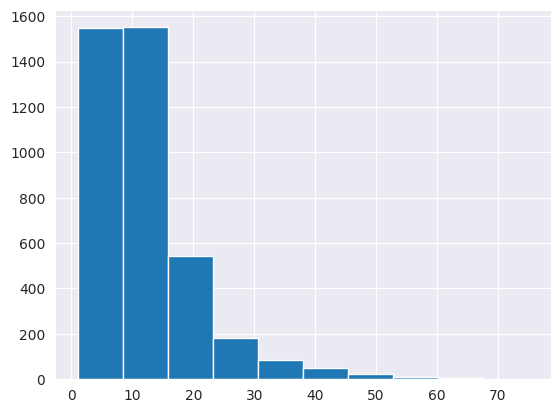

In [21]:
plt.hist(num_sentences)

In [22]:
preprocessed_dataset_documents = [" ".join(doc_sentences) for doc_sentences in preprocessed_dataset]

positive_processed_dataset_documents = [" ".join(doc_sentences) for doc_sentences in positive_processed_dataset]
negative_processed_dataset_documents = [" ".join(doc_sentences) for doc_sentences in negative_processed_dataset]


In [23]:
d1 = positive_processed_dataset_documents[0]
doc1 = nlp(d1)


# New Version

In [24]:
import spacy
import torch
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
import logging
from torch_geometric.data import HeteroData
from transformers import AutoTokenizer, AutoModel
from torch.nn.functional import cosine_similarity, softmax, one_hot

# --- Setup Logging ---
logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s - %(levelname)s - %(message)s'
)

# --- Constants and Configuration ---
COMMON_DEP_LABELS = [
    "nsubj", "obj", "iobj", "csubj", "ccomp", "xcomp", "obl", "amod", "advmod",
    "det", "case", "mark", "nmod", "acl", "conj", "cc", "punct", "root", "dep"
]


def get_positional_encoding(max_len: int, d_model: int) -> torch.Tensor:
    """Generates sinusoidal positional encodings."""
    pe = torch.zeros(max_len, d_model)
    position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
    div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-np.log(10000.0) / d_model))
    pe[:, 0::2] = torch.sin(position * div_term)
    pe[:, 1::2] = torch.cos(position * div_term)
    return pe


class DocumentGraphBuilder:
    """
    A class to build multi-level, heterogeneous graphs from textual documents.
    This version includes the fix for the IndexError.
    """

    def __init__(self,
                 spacy_model: str = 'en_core_web_lg',
                 embedding_model: str = 'sentence-transformers/all-MiniLM-L6-v2',
                 similarity_threshold: float = 0.9,
                 pos_embedding_dim: int = 32):
        logging.info("Initializing DocumentGraphBuilder...")
        self.nlp = spacy.load(spacy_model)
        self.tokenizer = AutoTokenizer.from_pretrained(embedding_model)
        self.model = AutoModel.from_pretrained(embedding_model)
        self.similarity_threshold = similarity_threshold
        self.pos_embedding_dim = pos_embedding_dim
        self.dep_label_map = {label: i for i, label in enumerate(COMMON_DEP_LABELS)}
        self.embedding_dim = self.model.config.hidden_size  # Store embedding dimension
        logging.info("Models and configuration loaded successfully.")

    def _get_batch_embedding(self, texts: list[str]) -> torch.Tensor:
        """Generates embeddings for a batch of texts."""
        inputs = self.tokenizer(texts, return_tensors='pt', padding=True, truncation=True)
        with torch.no_grad():
            outputs = self.model(**inputs)
        return outputs.last_hidden_state.mean(dim=1)

    def process_documents(self, documents: list[str]) -> tuple[list[nx.MultiDiGraph], list[HeteroData]]:
        """Processes a list of documents and returns their graph representations."""
        nx_graphs = []
        hetero_graphs = []
        for i, doc_text in enumerate(documents):
            logging.info(f"--- Processing Document {i + 1}/{len(documents)} ---")
            nx_graph, hetero_graph = self.build_graphs_for_document(doc_text, doc_id=i)
            nx_graphs.append(nx_graph)
            hetero_graphs.append(hetero_graph)
        return nx_graphs, hetero_graphs

    def build_graphs_for_document(self, doc_text: str, doc_id: int) -> tuple[nx.MultiDiGraph, HeteroData]:
        """Constructs both graph representations for a single document."""
        spacy_doc = self.nlp(doc_text)
        sentences = list(spacy_doc.sents)
        nx_graph = nx.MultiDiGraph(doc_id=doc_id, text=doc_text)
        doc_node_id = f"doc_{doc_id}"

        if not sentences:
            logging.warning(f"Document {doc_id} is empty. Creating empty graph with only a document node.")
            nx_graph.add_node(doc_node_id, type='document', text=f"DOC_{doc_id}",
                              x=torch.zeros((1, self.embedding_dim)))
            return nx_graph, HeteroData()

        all_word_texts = [tok.text for tok in spacy_doc if not tok.is_stop and not tok.is_punct]
        if not all_word_texts:
            logging.warning(f"Document {doc_id} has no valid words. Creating empty graph with only a document node.")
            nx_graph.add_node(doc_node_id, type='document', text=f"DOC_{doc_id}",
                              x=torch.zeros((1, self.embedding_dim)))
            return nx_graph, HeteroData()

        unique_words = sorted(list(set(all_word_texts)))
        word_embeddings_map = {word: emb for word, emb in zip(unique_words, self._get_batch_embedding(unique_words))}
        max_sent_len = max((len(list(s)) for s in sentences), default=0)
        positional_encodings = get_positional_encoding(max_sent_len, self.pos_embedding_dim)
        lemma_to_nodes = {}

        # FIX: Use a list to store data only for sentences that are successfully processed
        processed_sentences = []

        for sent_idx, sent in enumerate(sentences):
            word_nodes_in_sent, word_contextual_embs_in_sent = [], []
            for token in sent:
                if token.is_stop or token.is_punct: continue
                word_node_id = f"word_{doc_id}_{token.i}"
                contextual_emb = word_embeddings_map[token.text]
                word_contextual_embs_in_sent.append(contextual_emb)
                pos_in_sent = token.i - sent.start
                pos_emb = positional_encodings[pos_in_sent]
                combined_emb = torch.cat([contextual_emb, pos_emb]).unsqueeze(0)
                nx_graph.add_node(word_node_id, type='word', text=token.text, lemma=token.lemma_, pos=token.pos_,
                                  position_in_sentence=pos_in_sent, position_in_doc=token.i, x=combined_emb,
                                  contextual_x=contextual_emb.unsqueeze(0))
                word_nodes_in_sent.append(word_node_id)
                if token.lemma_ not in lemma_to_nodes: lemma_to_nodes[token.lemma_] = []
                lemma_to_nodes[token.lemma_].append(word_node_id)

            # If the sentence had no valid words, skip it entirely
            if not word_nodes_in_sent: continue

            prototype_sent_emb = torch.mean(torch.stack(word_contextual_embs_in_sent), dim=0)
            attention_scores = [cosine_similarity(emb.unsqueeze(0), prototype_sent_emb.unsqueeze(0)).item() for emb in
                                word_contextual_embs_in_sent]
            normalized_attentions = softmax(torch.tensor(attention_scores, dtype=torch.float), dim=0)
            final_sent_emb = torch.sum(normalized_attentions.unsqueeze(1) * torch.stack(word_contextual_embs_in_sent),
                                       dim=0).unsqueeze(0)

            sent_node_id = f"sent_{doc_id}_{sent_idx}"
            nx_graph.add_node(sent_node_id, type='sentence', text=sent.text, sentence_index=sent_idx, x=final_sent_emb)

            for i, wnid in enumerate(word_nodes_in_sent):
                nx_graph.add_edge(wnid, sent_node_id, type='belongs', attention=normalized_attentions[i].item())

            # FIX: Store the successfully processed sentence info
            processed_sentences.append({'id': sent_node_id, 'embedding': final_sent_emb})

        # FIX: Base all document-level calculations on the `processed_sentences` list
        final_sentence_embeddings = [s['embedding'] for s in processed_sentences]
        doc_embedding = torch.mean(torch.cat(final_sentence_embeddings), dim=0, keepdim=True)
        nx_graph.add_node(doc_node_id, type='document', text=f"DOC_{doc_id}", x=doc_embedding)

        doc_attentions = [cosine_similarity(sent_emb, doc_embedding).item() for sent_emb in final_sentence_embeddings]
        normalized_doc_attentions = softmax(torch.tensor(doc_attentions, dtype=torch.float), dim=0)

        # FIX: Iterate over the clean list, guaranteeing lengths match
        for i, sent_data in enumerate(processed_sentences):
            snid = sent_data['id']
            nx_graph.add_edge(snid, doc_node_id, type='belongs', attention=normalized_doc_attentions[i].item())

        # The rest of the edge creation logic remains the same
        for lemma, nodes in lemma_to_nodes.items():
            if len(nodes) > 1:
                for i in range(len(nodes)):
                    for j in range(i + 1, len(nodes)):
                        nx_graph.add_edge(nodes[i], nodes[j], type='same_lemma')
                        nx_graph.add_edge(nodes[j], nodes[i], type='same_lemma')
        for token in spacy_doc:
            if token.is_stop or token.is_punct: continue
            u_id = f"word_{doc_id}_{token.i}"
            if token.i + 1 < len(spacy_doc) and not spacy_doc[token.i + 1].is_stop and not spacy_doc[
                token.i + 1].is_punct and spacy_doc[token.i + 1].sent == token.sent:
                v_id = f"word_{doc_id}_{token.i + 1}"
                nx_graph.add_edge(u_id, v_id, type='seq')
            if token.head != token:
                v_id = f"word_{doc_id}_{token.head.i}"
                if nx_graph.has_node(v_id):
                    dep_idx = self.dep_label_map.get(token.dep_, self.dep_label_map['dep'])
                    dep_feature = one_hot(torch.tensor(dep_idx), num_classes=len(self.dep_label_map)).float()
                    nx_graph.add_edge(u_id, v_id, type='dep', feature=dep_feature)

        # Iterate over the processed sentences to add intra-sentence edges
        sentence_node_ids = [s['id'] for s in processed_sentences]
        for i in range(len(sentence_node_ids)):
            if i + 1 < len(sentence_node_ids):
                nx_graph.add_edge(sentence_node_ids[i], sentence_node_ids[i + 1], type='seq')
            for j in range(i + 1, len(sentence_node_ids)):
                sim = cosine_similarity(nx_graph.nodes[sentence_node_ids[i]]['x'],
                                        nx_graph.nodes[sentence_node_ids[j]]['x']).item()
                if sim > self.similarity_threshold:
                    nx_graph.add_edge(sentence_node_ids[i], sentence_node_ids[j], type='sim')

        logging.info(
            f"Constructed NetworkX graph: {nx_graph.number_of_nodes()} nodes, {nx_graph.number_of_edges()} edges.")
        hetero_data = self.to_hetero_data(nx_graph)
        logging.info(f"Converted to HeteroData graph: \n{hetero_data}")
        return nx_graph, hetero_data

    def to_hetero_data(self, nx_graph: nx.MultiDiGraph) -> HeteroData:
        data = HeteroData()
        node_types = {d['type'] for _, d in nx_graph.nodes(data=True)}
        node_mappings = {
            ntype: {n: i for i, n in enumerate(nd for nd, d in nx_graph.nodes(data=True) if d['type'] == ntype)} for
            ntype in node_types}
        for ntype, mapping in node_mappings.items():
            nodes_of_type = list(mapping.keys())
            if not nodes_of_type: continue
            for attr in nx_graph.nodes[nodes_of_type[0]].keys():
                if attr in ['type', 'contextual_x']: continue
                values = [nx_graph.nodes[n][attr] for n in nodes_of_type]
                try:
                    data[ntype][attr] = torch.cat(values, dim=0) if isinstance(values[0],
                                                                               torch.Tensor) else torch.tensor(values)
                except (TypeError, ValueError):
                    data[ntype][attr] = values
        for u, v, attrs in nx_graph.edges(data=True):
            src_type, dst_type = nx_graph.nodes[u]['type'], nx_graph.nodes[v]['type']
            edge_type = attrs['type']
            edge_tuple = (src_type, edge_type, dst_type)
            if u not in node_mappings[src_type] or v not in node_mappings[dst_type]: continue
            src_idx, dst_idx = node_mappings[src_type][u], node_mappings[dst_type][v]
            if 'edge_index' not in data[edge_tuple]: data[edge_tuple].edge_index = torch.empty((2, 0), dtype=torch.long)
            edge_index = torch.tensor([[src_idx], [dst_idx]], dtype=torch.long)
            data[edge_tuple].edge_index = torch.cat([data[edge_tuple].edge_index, edge_index], dim=1)
            for attr_key, attr_val in attrs.items():
                if attr_key == 'type': continue
                if attr_key not in data[edge_tuple]: data[edge_tuple][attr_key] = []
                data[edge_tuple][attr_key].append(attr_val)
        for store in data.edge_stores:
            for key, value in store.items():
                if key != 'edge_index' and isinstance(value, list):
                    try:
                        store[key] = torch.stack(value, dim=0) if isinstance(value[0], torch.Tensor) else torch.tensor(
                            value)
                    except (TypeError, ValueError):
                        pass
        return data



In [25]:
import spacy
import torch
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
import logging
from torch_geometric.data import HeteroData
from transformers import AutoTokenizer, AutoModel
from torch.nn.functional import cosine_similarity, softmax, one_hot
from matplotlib.lines import Line2D
from matplotlib.patches import Rectangle  # For drawing the grouping boxes
from pyvis.network import Network  # Import the new library


# --- Utility and Analysis Functions ---

def visualize_explanatory_graph(nx_graph: nx.MultiDiGraph):
    """
    Draws a high-quality, explanatory graph with advanced anti-overlap features.

    This final version introduces horizontal gaps between word groups for
    maximum clarity and visual separation.
    """
    fig, ax = plt.subplots(figsize=(70, 30))
    pos = {}

    # --- 1. Define Color and Style Maps ---
    node_color_map = {'document': '#d62828', 'sentence': '#003049', 'word': '#f77f00'}
    edge_color_map = {
        'belongs': '#2a9d8f', 'seq': '#e76f51', 'dep': '#8d99ae',
        'same_lemma': '#6a4c93', 'sim': '#118ab2'
    }

    # --- 2. Segregate nodes and prepare structures ---
    nodes_by_type = {'document': [], 'sentence': [], 'word': []}
    sent_to_words = {}
    for node, data in nx_graph.nodes(data=True):
        nodes_by_type[data['type']].append(node)
        if data['type'] == 'sentence':
            sent_to_words[node] = []

    for u, v, data in nx_graph.edges(data=True):
        if data.get('type') == 'belongs' and nx_graph.nodes[u]['type'] == 'word':
            sent_to_words[v].append(u)

    # --- 3. Calculate "Group Spread" Positions with Gaps ---
    y_coords = {'document': 1.0, 'sentence': 0.0, 'word': -1.0}
    pos[nodes_by_type['document'][0]] = (0.5, y_coords['document'])

    sorted_sents = sorted(nodes_by_type['sentence'], key=lambda n: nx_graph.nodes[n]['sentence_index'])
    num_sentences = len(sorted_sents)

    # Define the proportion of space used for groups vs. gaps
    total_plot_width = 0.9  # Use 90% of the figure for plotting, leaving margins
    left_margin = (1 - total_plot_width) / 2

    if num_sentences > 1:
        # NEW: Allocate space for gaps between groups
        group_space_ratio = 0.9  # 90% of space for groups, 10% for gaps
        total_group_width = total_plot_width * group_space_ratio
        total_gap_width = total_plot_width * (1 - group_space_ratio)

        single_group_width = total_group_width / num_sentences
        single_gap_width = total_gap_width / (num_sentences - 1)
    else:  # Handle case with only one sentence (no gaps needed)
        single_group_width = total_plot_width
        single_gap_width = 0

    current_x = left_margin
    for sent_node in sorted_sents:
        # Define the horizontal segment (lane) for this group
        x_start = current_x
        x_end = x_start + single_group_width

        # Position the sentence node in the middle of its segment
        sent_x = (x_start + x_end) / 2
        pos[sent_node] = (sent_x, y_coords['sentence'])

        # Position word nodes within the sentence's dedicated segment
        words_in_sent = sorted(sent_to_words[sent_node], key=lambda n: nx_graph.nodes[n]['position_in_doc'])
        num_words = len(words_in_sent)

        padding = 0.1 * single_group_width  # Padding is relative to group width
        word_x_coords = np.linspace(x_start + padding, x_end - padding, num_words) if num_words > 1 else [sent_x]

        y_base = y_coords['word']
        y_stagger_offset = 0.2
        for j, word_node in enumerate(words_in_sent):
            y_pos = y_base if j % 2 == 0 else y_base - y_stagger_offset
            pos[word_node] = (word_x_coords[j], y_pos)

        # Add a visual "grouping box"
        rect = Rectangle((x_start, y_coords['word'] - y_stagger_offset - 0.1),
                         width=single_group_width, height=0.4 + y_stagger_offset,
                         facecolor='#f8f9fa', edgecolor='#ced4da', linestyle='--', alpha=0.6, zorder=0)
        ax.add_patch(rect)

        # Move the cursor for the next group
        current_x = x_end + single_gap_width

    # --- 4. Prepare Labels, Colors, and Dynamic Node Sizes ---
    labels, node_colors, node_sizes = {}, [], []
    for node, data in nx_graph.nodes(data=True):
        node_colors.append(node_color_map[data['type']])
        text_label = data['text']
        if data['type'] == 'word':
            labels[node] = text_label
            node_sizes.append(1000 + len(text_label) * 250)
        elif data['type'] == 'sentence':
            labels[node] = f"SENT_{data['sentence_index']}"
            node_sizes.append(5000)
        else:
            labels[node] = text_label
            node_sizes.append(6000)

    # --- 5. Draw the graph elements ---
    nx.draw_networkx_nodes(nx_graph, pos, node_color=node_colors, node_size=node_sizes, alpha=1.0, ax=ax)
    nx.draw_networkx_labels(nx_graph, pos, labels=labels, font_size=9, font_weight='bold', font_color='white', ax=ax)

    for u, v, data in nx_graph.edges(data=True):
        edge_type, edge_color = data['type'], edge_color_map.get(data['type'], '#b7b7a4')
        alpha = max(0.15, data.get('attention', 0.8)) if edge_type == 'belongs' else 0.7
        rad = 0.15
        if hash(u) > hash(v): rad = -rad
        if nx_graph.nodes[u]['type'] == nx_graph.nodes[v]['type']: rad = 0.2

        ax.annotate("", xy=pos[v], xycoords='data', xytext=pos[u], textcoords='data',
                    arrowprops=dict(arrowstyle="->", color=edge_color, alpha=alpha, lw=2.0,
                                    shrinkA=35, shrinkB=35, patchA=None, patchB=None,
                                    connectionstyle=f"arc3,rad={rad}"))

    # --- 6. Create and Add the Legend ---
    legend_handles = []
    for node_type, color in node_color_map.items():
        legend_handles.append(Line2D([0], [0], marker='o', color='w', label=f'Node: {node_type.capitalize()}',
                                     markersize=15, markerfacecolor=color))
    for edge_type, color in edge_color_map.items():
        label = f'Edge: {edge_type.capitalize()}'
        if edge_type == 'belongs': label += ' (Opacity = Attention)'
        legend_handles.append(Line2D([0], [0], color=color, lw=4, label=label))

    ax.legend(handles=legend_handles, loc='upper center', bbox_to_anchor=(0.5, -0.02),
              fancybox=True, shadow=True, ncol=4, fontsize=14)
    ax.set_title(f"Explanatory Graph (Doc ID: {nx_graph.graph.get('doc_id', 'N/A')})", size=28, pad=20)
    plt.subplots_adjust(bottom=0.1, top=0.95)
    plt.axis('off')
    plt.show()


# --- New Interactive Visualization Function ---

def visualize_interactive_graph(nx_graph: nx.MultiDiGraph, output_filename: str = "interactive_graph.html"):
    """
    Creates a beautiful, interactive, physics-based graph visualization
    using the pyvis library, similar to Neo4j's browser.

    Args:
        nx_graph (nx.MultiDiGraph): The graph to visualize.
        output_filename (str): The name of the HTML file to save.
    """
    logging.info(f"Creating interactive graph, saving to {output_filename}...")

    # --- 1. Setup Pyvis Network ---
    # We define the size of the canvas and tell it to use a dark theme.
    # The `notebook=True` argument is crucial for displaying in Jupyter.
    net = Network(height="800px", width="100%", bgcolor="#222222", font_color="white", notebook=True,
                  cdn_resources='in_line')

    # --- 2. Define Color and Style Maps ---
    node_color_map = {'document': '#d62828', 'sentence': '#003049', 'word': '#f77f00'}
    edge_color_map = {
        'belongs': '#2a9d8f', 'seq': '#e76f51', 'dep': '#8d99ae',
        'same_lemma': '#6a4c93', 'sim': '#118ab2'
    }

    # --- 3. Add Nodes to the Pyvis Network ---
    # We iterate through each node in our NetworkX graph and add it to pyvis,
    # mapping our data attributes to pyvis's visual properties.
    for node, data in nx_graph.nodes(data=True):
        node_type = data['type']
        label = data['text']

        # The 'title' attribute creates the hover-over tooltip
        if node_type == 'sentence':
            title = f"Type: Sentence\nText: {label}"
            label = f"SENT_{data['sentence_index']}"
        else:
            title = f"Type: {node_type.capitalize()}\nText: {label}"

        # Dynamic sizing for nodes
        if node_type == 'document':
            size = 30
        elif node_type == 'sentence':
            size = 20
        else:
            size = 10 + len(label)  # Word nodes

        net.add_node(
            node,
            label=label,
            title=title,
            color=node_color_map.get(node_type, 'grey'),
            size=size
        )

    # --- 4. Add Edges to the Pyvis Network ---
    # We do the same for edges, mapping attention to edge width.
    for u, v, data in nx_graph.edges(data=True):
        edge_type = data['type']

        # Map attention to edge width for hierarchical 'belongs' edges
        if edge_type == 'belongs':
            # Scale attention (0-1) to a visible width range (e.g., 1-10)
            width = 1 + data.get('attention', 0.5) * 9
            title = f"Type: Belongs\nAttention: {data.get('attention', 0):.4f}"
        else:
            width = 2
            title = f"Type: {edge_type.capitalize()}"

        net.add_edge(
            u, v,
            title=title,
            color=edge_color_map.get(edge_type, 'grey'),
            width=width
        )

    # --- 5. Configure Physics and Show the Graph ---
    # Add a UI to toggle physics on and off for better exploration
    net.show_buttons(filter_=['physics'])

    # Generate the HTML file
    try:
        net.save_graph(output_filename)
        logging.info("Successfully saved interactive graph.")
    except Exception as e:
        logging.error(f"Could not save interactive graph: {e}")


def extract_explanations(nx_graph: nx.MultiDiGraph) -> dict:
    """Extracts top words and sentences based on their attention scores."""
    # Implementation remains the same
    explanations = {"top_sentences": [], "top_words_per_sentence": {}}
    sent_attentions = []
    for u, v, data in nx_graph.edges(data=True):
        if nx_graph.nodes[u]['type'] == 'sentence' and nx_graph.nodes[v]['type'] == 'document':
            sent_attentions.append((nx_graph.nodes[u]['text'], data['attention']))
    explanations['top_sentences'] = sorted(sent_attentions, key=lambda x: x[1], reverse=True)
    sentences_nodes = [n for n, d in nx_graph.nodes(data=True) if d['type'] == 'sentence']
    for sent_node in sentences_nodes:
        word_attentions = []
        for u, v, data in nx_graph.in_edges(sent_node, data=True):
            if nx_graph.nodes[u]['type'] == 'word':
                word_attentions.append((nx_graph.nodes[u]['text'], data['attention']))
        explanations["top_words_per_sentence"][nx_graph.nodes[sent_node]['text']] = sorted(word_attentions,
                                                                                           key=lambda x: x[1],
                                                                                           reverse=True)
    return explanations


## Main Execution Block

In [26]:
sample_documents = positive_processed_dataset_documents[:5]

In [27]:
graph_builder = DocumentGraphBuilder()
nx_graphs, hetero_graphs = graph_builder.process_documents(sample_documents)

2025-06-08 22:18:50,757 - INFO - Initializing DocumentGraphBuilder...
2025-06-08 22:19:07,951 - INFO - Models and configuration loaded successfully.
2025-06-08 22:19:07,952 - INFO - --- Processing Document 1/5 ---
2025-06-08 22:19:08,094 - INFO - Constructed NetworkX graph: 110 nodes, 217 edges.
2025-06-08 22:19:08,106 - INFO - Converted to HeteroData graph: 
HeteroData(
  word={
    text=[95],
    lemma=[95],
    pos=[95],
    position_in_sentence=[95],
    position_in_doc=[95],
    x=[95, 416],
  },
  sentence={
    text=[14],
    sentence_index=[14],
    x=[14, 384],
  },
  document={
    text=[1],
    x=[1, 384],
  },
  (word, belongs, sentence)={
    edge_index=[2, 95],
    attention=[95],
  },
  (word, same_lemma, word)={ edge_index=[2, 28] },
  (word, dep, word)={
    edge_index=[2, 44],
    feature=[44, 19],
  },
  (word, seq, word)={ edge_index=[2, 20] },
  (sentence, belongs, document)={
    edge_index=[2, 14],
    attention=[14],
  },
  (sentence, seq, sentence)={ edge_index



--- Analysis of Document 1: 
"on one level, this film can bring out the child in us that just wants to build sandcastles and throw stuff in the air just for the sake of seeing it fall down again. on a deeper level though, it explores a profound desire to reconnect with the land. I thoroughly empathized with the artist when he said, when I am not out here (alone) for any length of time, I feel unrooted. I considered Andy Goldsworthy one of the great contemporary artists. I am familiar with his works mainly through his coffee-table books and a couple art gallery installations. but to see his work in motion, captured perfectly through Riedelsheimer's lens, was a revelation. unfrozen in time, Goldsworthy's creations come alive, swirling, flying, dissolving, crumbling, crashing. and that is precisely what he is all about: Time. the process of creation and destruction. of emergence and disappearing. of coming out of the Void and becoming the universe, and back again. there is a shamanic qu

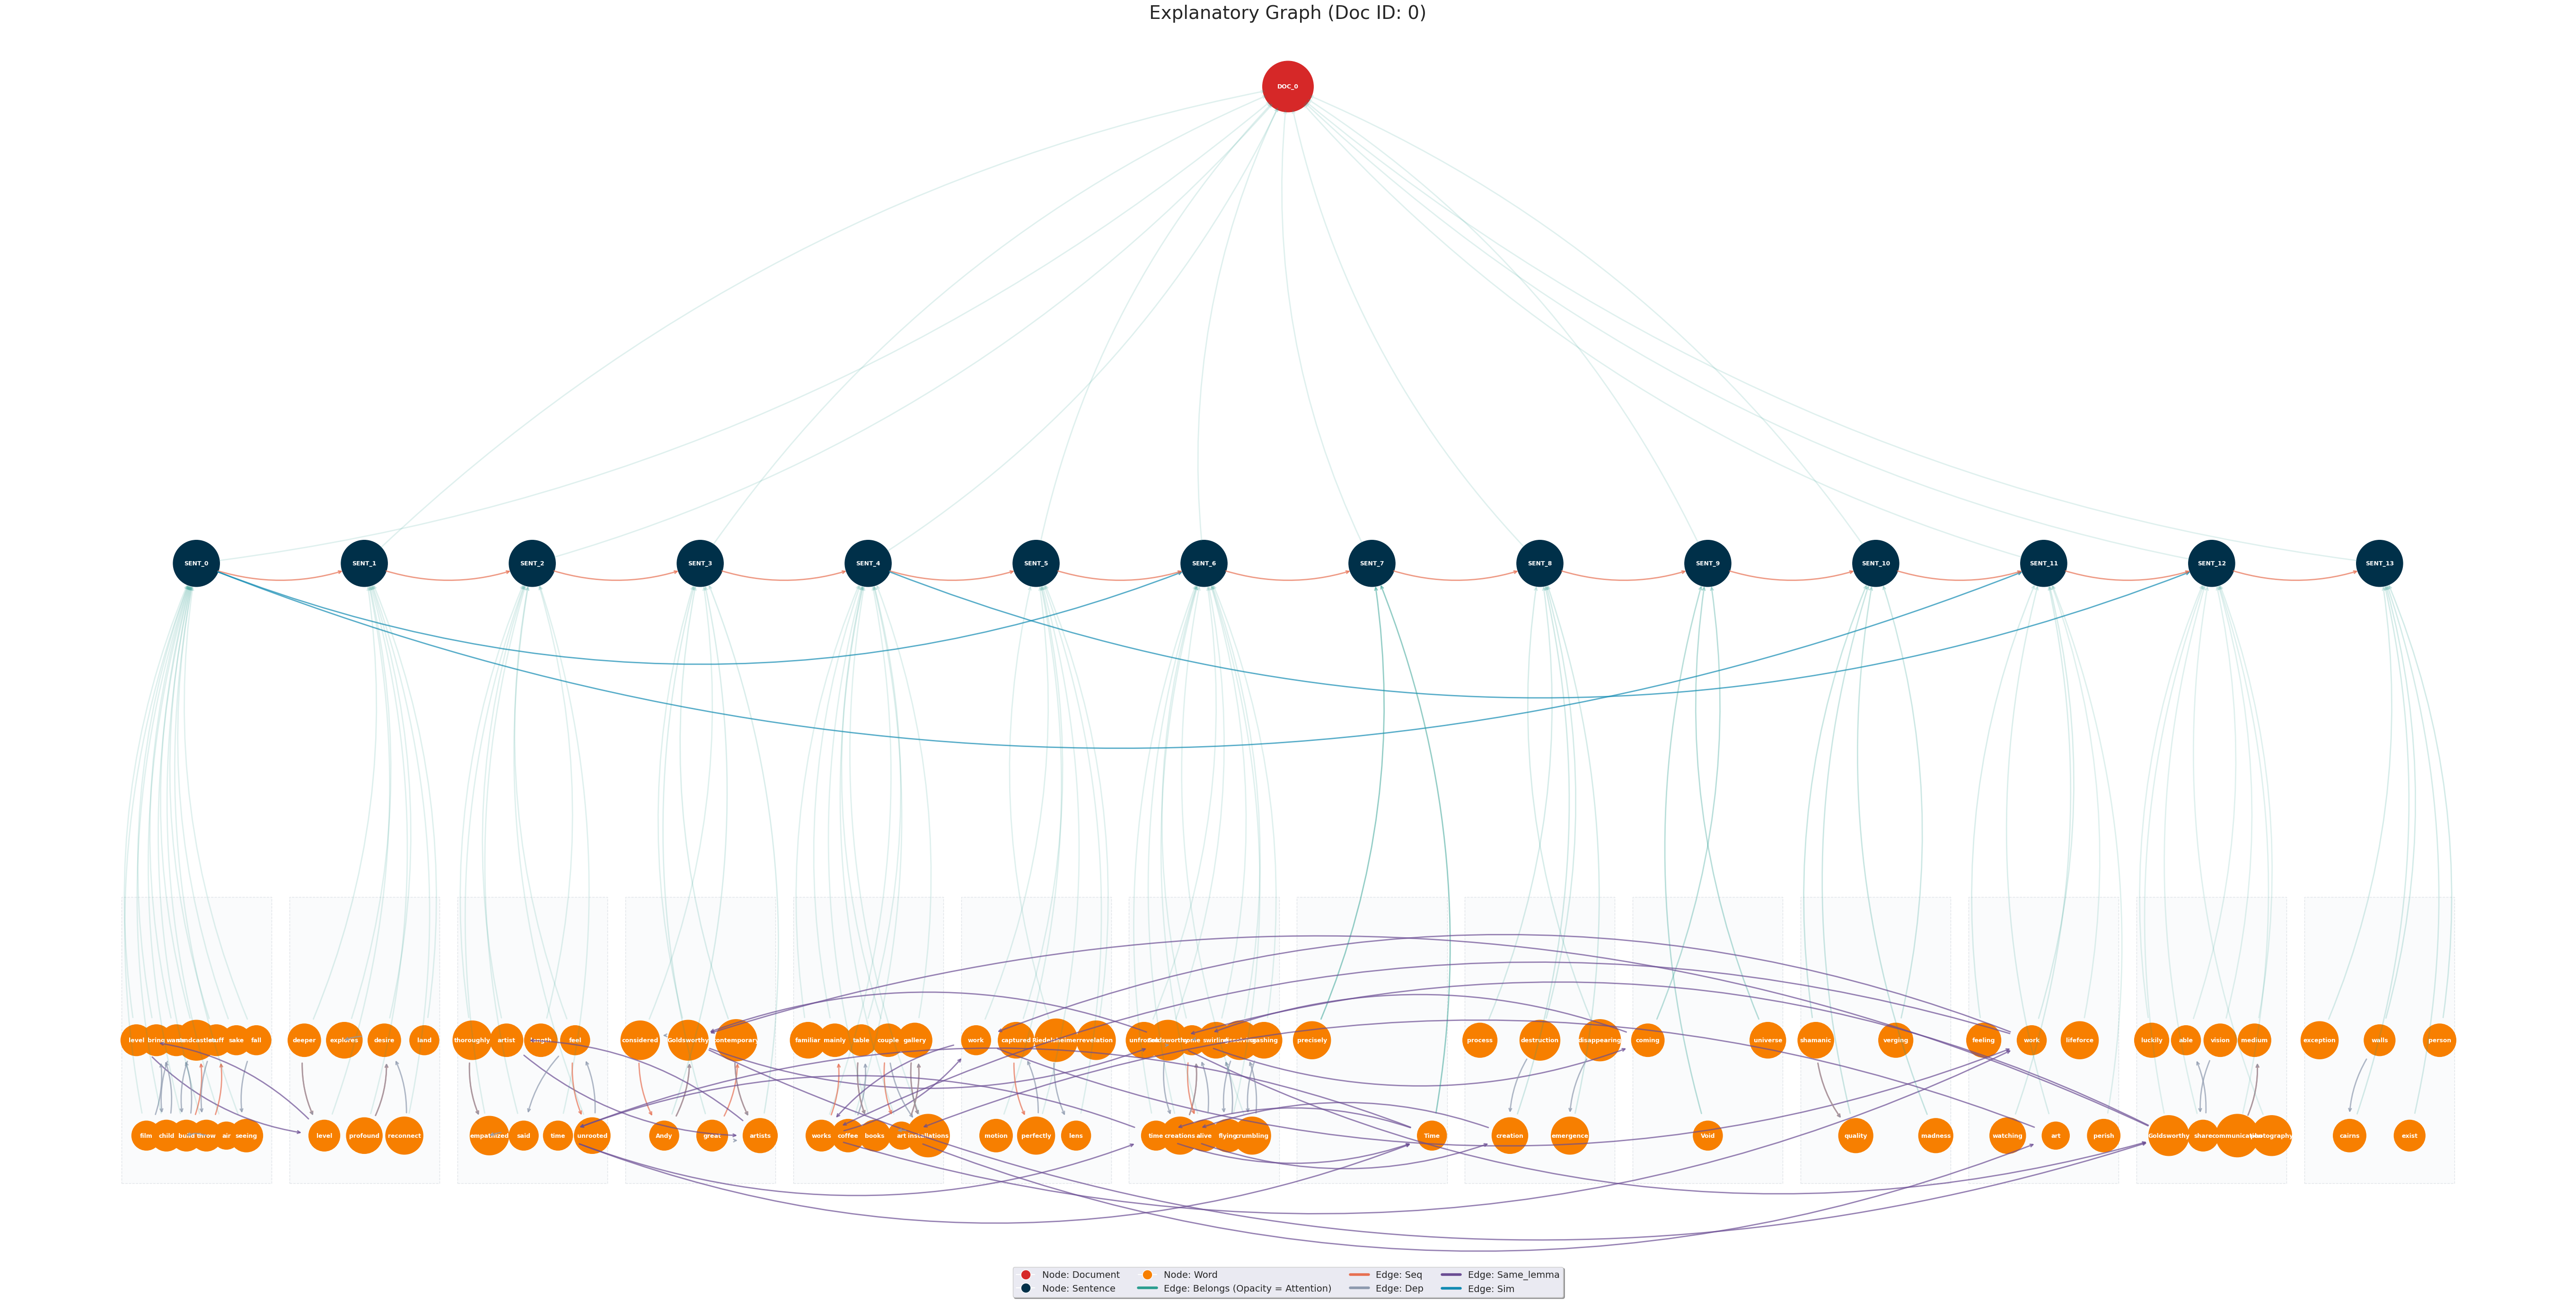

In [28]:
# --- Analysis and Visualization of Document 1 ---
print("\n\n" + "=" * 50)
print(f"--- Analysis of Document 1: \n\"{sample_documents[0]}\"\n ---")
print("=" * 50)

doc1_nx = nx_graphs[0]

# Extract and show explanations
explanations = extract_explanations(doc1_nx)
print("\n[INFO] Explanations (via Semantic Attention):")
print("Top Sentences:")
for text, score in explanations['top_sentences']:
    print(f"  - Score: {score:.4f}, Text: '{text}'")

# Generate and show the new hierarchical visualization
# Generate and show the new explanatory visualization
print("\n[INFO] Generating explanatory graph visualization for Document 1...")
visualize_explanatory_graph(doc1_nx)


In [29]:
 # --- Call the NEW interactive visualization function ---
# This will create an HTML file in your directory.
# If you are in a Jupyter Notebook, it will also display the graph inline.
visualize_interactive_graph(doc1_nx, output_filename="final_interactive_document_graph.html")
print("\nInteractive graph has been generated and saved as 'final_interactive_document_graph.html'.")
print("Open this file in a web browser to zoom, drag nodes, and explore the graph.")

2025-06-08 22:19:24,962 - INFO - Creating interactive graph, saving to final_interactive_document_graph.html...
2025-06-08 22:19:25,143 - INFO - Successfully saved interactive graph.



Interactive graph has been generated and saved as 'final_interactive_document_graph.html'.
Open this file in a web browser to zoom, drag nodes, and explore the graph.


In [30]:
import torch
import torch.nn.functional as F
from torch.nn import Linear
import torch_geometric.transforms as T
from torch_geometric.data import HeteroData
from torch_geometric.loader import DataLoader
from torch_geometric.nn import SAGEConv, GATv2Conv, HeteroConv, global_mean_pool

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Assume 'DocumentGraphBuilder' from the previous step is in a file named 'graph_builder.py'
# from graph_builder import DocumentGraphBuilder


In [31]:
import itertools


# --- 1. Data Simulation and Preparation ---
def prepare_dataset():
    """
    Simulates a raw dataset and processes it using DocumentGraphBuilder.
    """
    # For demonstration, we'll create dummy documents for N classes.
    # In a real scenario, you would load your actual text files here.
    documents_by_class = {
        "positive": positive_processed_dataset_documents,
        "negative": negative_processed_dataset_documents
    }

    class_names = list(documents_by_class.keys())

    graph_builder = DocumentGraphBuilder()
    graph_list = []
    labels_list = []

    for class_idx, (class_name, docs) in enumerate(documents_by_class.items()):
        print(f"\n--- Processing Class: {class_name} ---")
        _, hetero_graphs = graph_builder.process_documents(docs)
        graph_list.extend(hetero_graphs)
        labels_list.extend([class_idx] * len(hetero_graphs))

    return graph_list, labels_list, class_names

In [32]:

# --- 2. GNN Model Definition ---

class HeteroGNN(torch.nn.Module):
    """
    A Heterogeneous Graph Neural Network for graph-level classification.
    """

    def __init__(self, hidden_channels, out_channels, num_layers=2):
        super().__init__()

        self.convs = torch.nn.ModuleList()
        for _ in range(num_layers):
            conv = HeteroConv({
                ('word', 'seq', 'word'): SAGEConv(-1, hidden_channels, aggr='mean'),
                ('word', 'dep', 'word'): SAGEConv(-1, hidden_channels, aggr='mean'),
                ('sentence', 'seq', 'sentence'): SAGEConv(-1, hidden_channels, aggr='mean'),
                ('word', 'same_lemma', 'word'): SAGEConv(-1, hidden_channels, aggr='mean'),
                ('sentence', 'sim', 'sentence'): SAGEConv(-1, hidden_channels, aggr='mean'),
                ('word', 'belongs', 'sentence'): GATv2Conv((-1, -1), hidden_channels, add_self_loops=False),
                ('sentence', 'belongs', 'document'): GATv2Conv((-1, -1), hidden_channels, add_self_loops=False),
                ('sentence', 'rev_belongs', 'word'): SAGEConv(-1, hidden_channels, aggr='mean'),
                ('document', 'rev_belongs', 'sentence'): SAGEConv(-1, hidden_channels, aggr='mean'),
                ('word', 'rev_dep', 'word'): SAGEConv(-1, hidden_channels, aggr='mean'),
                ('word', 'rev_seq', 'word'): SAGEConv(-1, hidden_channels, aggr='mean'),
                ('sentence', 'rev_seq', 'sentence'): SAGEConv(-1, hidden_channels, aggr='mean'),
            }, aggr='sum')
            self.convs.append(conv)

        self.lin = Linear(hidden_channels, out_channels)

    def forward(self, data, return_attention_for_explainability=False):
        x_dict, edge_index_dict = data.x_dict, data.edge_index_dict
        attention_storage = {}

        for i, conv in enumerate(self.convs):
            # For explainability, we need to get attention weights from GAT layers
            if return_attention_for_explainability and i == 0:
                # The GATv2Conv layer for word->sentence edges
                gat_layer = conv.convs['word__belongs__sentence']

                # Perform the convolution and request attention weights
                x_word, (edge_index, alpha) = gat_layer(
                    (x_dict['word'], x_dict['sentence']),
                    edge_index_dict[('word', 'belongs', 'sentence')],
                    return_attention_weights=True
                )
                attention_storage['word_to_sentence'] = alpha

                # To get a valid forward pass, we need to manually update the output dict
                # This is a bit of a hack for explainability. A more robust solution might
                # involve custom layers, but this works for demonstration.
                out_dict = conv(x_dict, edge_index_dict)
                out_dict['sentence'] = x_word  # Overwrite with the result from our GAT call
                x_dict = out_dict
            else:
                x_dict = conv(x_dict, edge_index_dict)

            x_dict = {key: x.relu() for key, x in x_dict.items()}

        doc_embedding = x_dict['document']
        out = self.lin(doc_embedding)

        if return_attention_for_explainability:
            return out, attention_storage
        return out

In [33]:

# --- 3. Training and Evaluation Loop ---

def train(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0
    for data in loader:
        optimizer.zero_grad()
        data = T.ToUndirected(merge=False)(data)
        out = model(data)
        loss = criterion(out, data['document'].y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * data.num_graphs
    return total_loss / len(loader.dataset)


@torch.no_grad()
def test(model, loader):
    model.eval()
    total_correct = 0
    all_preds, all_labels = [], []
    for data in loader:
        data = T.ToUndirected(merge=False)(data)
        out = model(data)
        pred = out.argmax(dim=-1)
        total_correct += int((pred == data['document'].y).sum())
        all_preds.extend(pred.cpu().numpy())
        all_labels.extend(data['document'].y.cpu().numpy())
    accuracy = total_correct / len(loader.dataset)
    precision, recall, f1, _ = precision_recall_fscore_support(all_labels, all_preds, average='weighted',
                                                               zero_division=0)
    return accuracy, precision, recall, f1, all_labels, all_preds


2025-06-08 22:19:39,424 - INFO - Initializing DocumentGraphBuilder...
2025-06-08 22:19:42,636 - INFO - Models and configuration loaded successfully.
2025-06-08 22:19:42,638 - INFO - --- Processing Document 1/2000 ---
2025-06-08 22:19:42,835 - INFO - Constructed NetworkX graph: 110 nodes, 217 edges.



--- Processing Class: positive ---


2025-06-08 22:19:42,844 - INFO - Converted to HeteroData graph: 
HeteroData(
  word={
    text=[95],
    lemma=[95],
    pos=[95],
    position_in_sentence=[95],
    position_in_doc=[95],
    x=[95, 416],
  },
  sentence={
    text=[14],
    sentence_index=[14],
    x=[14, 384],
  },
  document={
    text=[1],
    x=[1, 384],
  },
  (word, belongs, sentence)={
    edge_index=[2, 95],
    attention=[95],
  },
  (word, same_lemma, word)={ edge_index=[2, 28] },
  (word, dep, word)={
    edge_index=[2, 44],
    feature=[44, 19],
  },
  (word, seq, word)={ edge_index=[2, 20] },
  (sentence, belongs, document)={
    edge_index=[2, 14],
    attention=[14],
  },
  (sentence, seq, sentence)={ edge_index=[2, 13] },
  (sentence, sim, sentence)={ edge_index=[2, 3] }
)
2025-06-08 22:19:42,845 - INFO - --- Processing Document 2/2000 ---
2025-06-08 22:19:43,188 - INFO - Constructed NetworkX graph: 257 nodes, 956 edges.
2025-06-08 22:19:43,224 - INFO - Converted to HeteroData graph: 
HeteroData(
  wor


--- Processing Class: negative ---


2025-06-08 22:22:49,727 - INFO - Constructed NetworkX graph: 68 nodes, 149 edges.
2025-06-08 22:22:49,731 - INFO - Converted to HeteroData graph: 
HeteroData(
  word={
    text=[61],
    lemma=[61],
    pos=[61],
    position_in_sentence=[61],
    position_in_doc=[61],
    x=[61, 416],
  },
  sentence={
    text=[6],
    sentence_index=[6],
    x=[6, 384],
  },
  document={
    text=[1],
    x=[1, 384],
  },
  (word, belongs, sentence)={
    edge_index=[2, 61],
    attention=[61],
  },
  (word, same_lemma, word)={ edge_index=[2, 24] },
  (sentence, belongs, document)={
    edge_index=[2, 6],
    attention=[6],
  },
  (sentence, seq, sentence)={ edge_index=[2, 5] },
  (word, seq, word)={ edge_index=[2, 18] },
  (word, dep, word)={
    edge_index=[2, 32],
    feature=[32, 19],
  },
  (sentence, sim, sentence)={ edge_index=[2, 3] }
)
2025-06-08 22:22:49,732 - INFO - --- Processing Document 4/2000 ---
2025-06-08 22:22:49,779 - INFO - Constructed NetworkX graph: 87 nodes, 206 edges.
2025-06

Dataset split: Train=2800, Val=600, Test=600
Epoch 10, Loss: 0.1707, Val Acc: 0.8150, Val F1: 0.8144
Epoch 20, Loss: 0.0565, Val Acc: 0.8167, Val F1: 0.8166
Epoch 30, Loss: 0.0533, Val Acc: 0.7733, Val F1: 0.7702
Epoch 40, Loss: 0.0601, Val Acc: 0.8267, Val F1: 0.8266
Epoch 50, Loss: 0.0006, Val Acc: 0.8233, Val F1: 0.8233

--- Final Evaluation on Test Set ---


/tmp/ipykernel_16869/3240740175.py:39: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load('best_model.pth'))


Test Accuracy:  0.8117
Test Precision: 0.8118
Test Recall:    0.8117
Test F1-Score:  0.8116


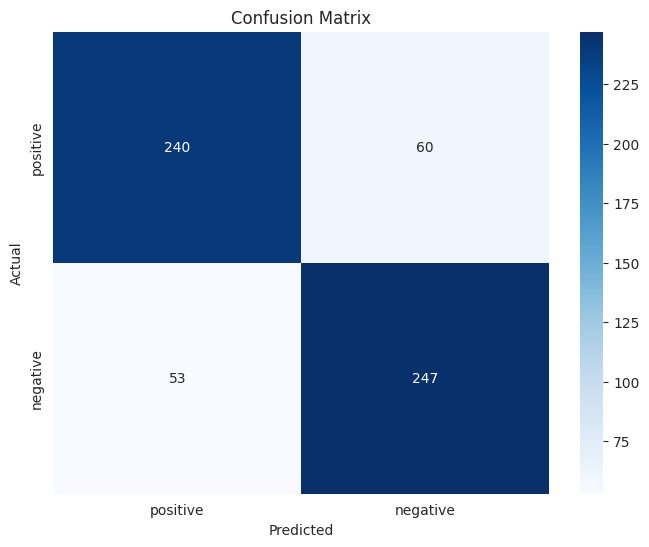


--- Explainability: Analyzing Attention Scores ---

Could not generate full attention explanation due to an error: 'word__belongs__sentence'


Traceback (most recent call last):
  File "/tmp/ipykernel_16869/3240740175.py", line 61, in <module>
    _, attentions = model(explain_data, return_attention_for_explainability=True)
  File "/home/trdp/Software/anaconda3/envs/phd_env/lib/python3.10/site-packages/torch/nn/modules/module.py", line 1553, in _wrapped_call_impl
    return self._call_impl(*args, **kwargs)
  File "/home/trdp/Software/anaconda3/envs/phd_env/lib/python3.10/site-packages/torch/nn/modules/module.py", line 1562, in _call_impl
    return forward_call(*args, **kwargs)
  File "/tmp/ipykernel_16869/726282076.py", line 39, in forward
    gat_layer = conv.convs['word__belongs__sentence']
  File "/home/trdp/Software/anaconda3/envs/phd_env/lib/python3.10/site-packages/torch_geometric/nn/module_dict.py", line 54, in __getitem__
    return super().__getitem__(self.to_internal_key(key))
  File "/home/trdp/Software/anaconda3/envs/phd_env/lib/python3.10/site-packages/torch/nn/modules/container.py", line 463, in __getitem__
   

In [34]:

# --- 4. Main Execution ---
if __name__ == '__main__':

    # 1. Prepare Data
    graphs, labels, class_names = prepare_dataset()
    for i, graph in enumerate(graphs):
        graph['document'].y = torch.tensor([labels[i]])

    # 2. Stratified Split
    train_graphs, test_graphs = train_test_split(graphs, test_size=0.3, random_state=42, stratify=labels)
    val_graphs, test_graphs = train_test_split(test_graphs, test_size=0.5, random_state=42,
                                               stratify=[g['document'].y.item() for g in test_graphs])

    print(f"Dataset split: Train={len(train_graphs)}, Val={len(val_graphs)}, Test={len(test_graphs)}")

    # 3. Create DataLoaders
    train_loader = DataLoader(train_graphs, batch_size=16, shuffle=True)
    val_loader = DataLoader(val_graphs, batch_size=16)
    test_loader = DataLoader(test_graphs, batch_size=16)

    # 4. Initialize Model and Training Components
    model = HeteroGNN(hidden_channels=64, out_channels=len(class_names), num_layers=2)
    optimizer = torch.optim.AdamW(model.parameters(), lr=0.001)
    criterion = torch.nn.CrossEntropyLoss()

    # 5. Training Loop
    best_val_f1 = 0
    for epoch in range(1, 51):
        loss = train(model, train_loader, optimizer, criterion)
        val_acc, val_p, val_r, val_f1, _, _ = test(model, val_loader)
        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            torch.save(model.state_dict(), 'best_model.pth')
        if epoch % 10 == 0:
            print(f'Epoch {epoch:02d}, Loss: {loss:.4f}, Val Acc: {val_acc:.4f}, Val F1: {val_f1:.4f}')

    # 6. Final Evaluation
    print("\n--- Final Evaluation on Test Set ---")
    model.load_state_dict(torch.load('best_model.pth'))
    test_acc, test_p, test_r, test_f1, true_labels, pred_labels = test(model, test_loader)
    print(f'Test Accuracy:  {test_acc:.4f}')
    print(f'Test Precision: {test_p:.4f}')
    print(f'Test Recall:    {test_r:.4f}')
    print(f'Test F1-Score:  {test_f1:.4f}')

    cm = confusion_matrix(true_labels, pred_labels)
    plt.figure(figsize=(8, 6))
    sns.heatmap(pd.DataFrame(cm, index=class_names, columns=class_names), annot=True, cmap='Blues', fmt='g')
    plt.title('Confusion Matrix'), plt.ylabel('Actual'), plt.xlabel('Predicted')
    plt.show()

    # 7. Explainability
    print("\n--- Explainability: Analyzing Attention Scores ---")
    try:
        explain_graph = test_graphs[0]
        true_label_idx = explain_graph['document'].y.item()

        model.eval()
        with torch.no_grad():
            explain_data = T.ToUndirected(merge=False)(explain_graph)
            _, attentions = model(explain_data, return_attention_for_explainability=True)

        word_sent_attention = attentions['word_to_sentence']
        edge_index = explain_data['word', 'belongs', 'sentence'].edge_index
        word_nodes_text = [t for t in explain_graph['word'].text]  # Ensure text is a list
        sent_nodes_text = [t for t in explain_graph['sentence'].text]

        print(f"Analyzing attention for a document with true label: '{class_names[true_label_idx]}'")

        attention_data = []
        for i in range(edge_index.size(1)):
            word_idx, sent_idx = edge_index[0, i], edge_index[1, i]
            attention_data.append({
                'word': word_nodes_text[word_idx],
                'sentence': sent_nodes_text[sent_idx],
                'attention': word_sent_attention[i].item()
            })

        df = pd.DataFrame(attention_data)

        for sentence, group in df.groupby('sentence'):
            top_words = group.sort_values('attention', ascending=False).head(5)
            print(f"\nSentence: \"{sentence}\"")
            for _, row in top_words.iterrows():
                print(f"  - Word: '{row['word']}' | Learned Attention: {row['attention']:.4f}")

    except Exception as e:
        print(f"\nCould not generate full attention explanation due to an error: {e}")
        import traceback

        traceback.print_exc()